In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos Preprocesados

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

X_train_scaled = np.load('../data/processed/X_train_scaled.npy')
X_val_scaled = np.load('../data/processed/X_val_scaled.npy')
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')

X_train_pca = np.load('../data/processed/X_train_pca.npy')
X_val_pca = np.load('../data/processed/X_val_pca.npy')
X_test_pca = np.load('../data/processed/X_test_pca.npy')

with open('../data/processed/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f"X_train shape: {X_train.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"--- VALIDATION SET ---")
print(f"X_val shape: {X_val.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"X_val_pca shape: {X_val_pca.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"--- TEST SET ---")
print(f"X_test shape: {X_test.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (67229, 31)
X_train_scaled shape: (67229, 31)
X_train_pca shape: (67229, 19)
y_train shape: (67229,)
--- VALIDATION SET ---
X_val shape: (15175, 31)
X_val_scaled shape: (15175, 31)
X_val_pca shape: (15175, 19)
y_val shape: (15175,)
--- TEST SET ---
X_test shape: (22203, 31)
X_test_scaled shape: (22203, 31)
X_test_pca shape: (22203, 19)
y_test shape: (22203,)


## 2. Función para Evaluar Modelos

In [3]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evalúa un modelo de regresión y retorna las métricas.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Resultados para: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

In [4]:
def plot_predictions(y_true, y_pred, model_name, ax=None):
    """
    Plotea predicciones vs valores reales.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.scatter(y_true, y_pred, alpha=0.5)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
    
    ax.set_xlabel('Rendimiento Real')
    ax.set_ylabel('Rendimiento Predicho')
    ax.set_title(f'{model_name}\nPredicciones vs Reales')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    r2 = r2_score(y_true, y_pred)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', 
            transform=ax.transAxes, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

## 3. Regresión Lineal sobre Features Originales (X)

In [5]:
print("Entrenando Regresión Lineal sobre features originales (X)...")

lr_x = LinearRegression()
lr_x.fit(X_train_scaled, y_train)

y_train_pred_lr_x = lr_x.predict(X_train_scaled)
y_val_pred_lr_x = lr_x.predict(X_val_scaled)

print("\n--- CONJUNTO DE ENTRENAMIENTO ---")
results_lr_x_train = evaluate_model(y_train, y_train_pred_lr_x, "Linear Regression (X) - Train")

print("\n--- CONJUNTO DE VALIDACIÓN ---")
results_lr_x_val = evaluate_model(y_val, y_val_pred_lr_x, "Linear Regression (X) - Validation")

Entrenando Regresión Lineal sobre features originales (X)...

--- CONJUNTO DE ENTRENAMIENTO ---

Resultados para: Linear Regression (X) - Train
RMSE: 5374.2016
MAE:  2918.6411
R2:   0.3410

--- CONJUNTO DE VALIDACIÓN ---

Resultados para: Linear Regression (X) - Validation
RMSE: 3186.5909
MAE:  1822.0425
R2:   0.0957


In [6]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_x.coef_
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print("\nTop 15 features más importantes (por magnitud del coeficiente):")
print(coef_df.head(15)[['feature', 'coefficient']])


Top 15 features más importantes (por magnitud del coeficiente):
                  feature  coefficient
29       produccion_total  3765.138741
30     sup_sembrada_total -1848.988679
25        suelo_porc_sue1 -1783.095314
24         suelo_ind_prod -1066.404640
2       temperatura_mes_2  -898.541112
27  suelo_alcalin_encoded   671.920164
26       suelo_profund_s1  -469.154826
12      temperatura_mes_7  -454.227248
4       temperatura_mes_3   358.936505
14      temperatura_mes_8   356.931126
6       temperatura_mes_4   355.698347
20     temperatura_mes_11   301.340539
16      temperatura_mes_9   243.927351
17    precipitacion_mes_9  -211.163352
28        cultivo_encoded   204.599280


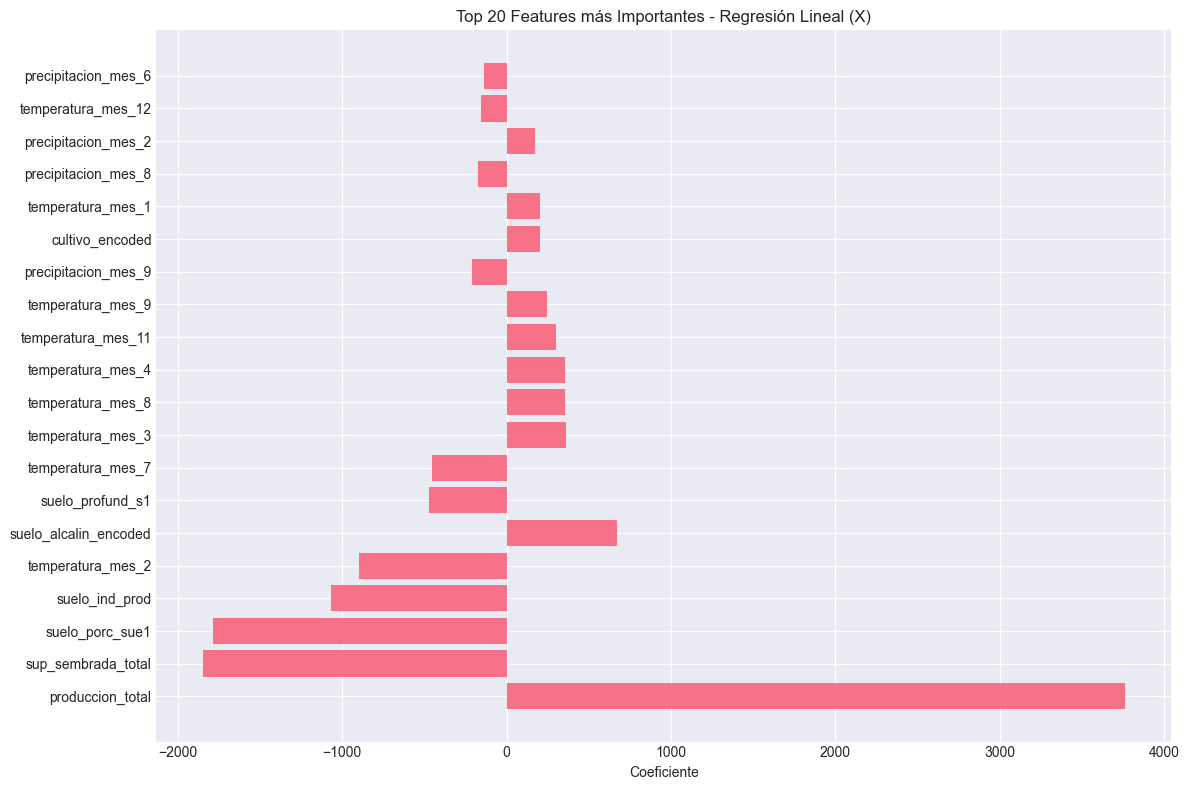

In [7]:
plt.figure(figsize=(12, 8))
top_n = 20
top_features = coef_df.head(top_n)

plt.barh(range(top_n), top_features['coefficient'].values)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Coeficiente')
plt.title(f'Top {top_n} Features más Importantes - Regresión Lineal (X)')
plt.tight_layout()
plt.savefig('../figures/lr_x_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Regresión Lineal sobre Componentes Principales (Z)

In [8]:
print("Entrenando Regresión Lineal sobre componentes principales (Z)...")

lr_z = LinearRegression()
lr_z.fit(X_train_pca, y_train)

y_train_pred_lr_z = lr_z.predict(X_train_pca)
y_val_pred_lr_z = lr_z.predict(X_val_pca)

print("\n--- CONJUNTO DE ENTRENAMIENTO ---")
results_lr_z_train = evaluate_model(y_train, y_train_pred_lr_z, "Linear Regression (Z-PCA) - Train")

print("\n--- CONJUNTO DE VALIDACIÓN ---")
results_lr_z_val = evaluate_model(y_val, y_val_pred_lr_z, "Linear Regression (Z-PCA) - Validation")

Entrenando Regresión Lineal sobre componentes principales (Z)...

--- CONJUNTO DE ENTRENAMIENTO ---

Resultados para: Linear Regression (Z-PCA) - Train
RMSE: 5431.0945
MAE:  2946.0618
R2:   0.3270

--- CONJUNTO DE VALIDACIÓN ---

Resultados para: Linear Regression (Z-PCA) - Validation
RMSE: 3128.2310
MAE:  1785.7457
R2:   0.1285


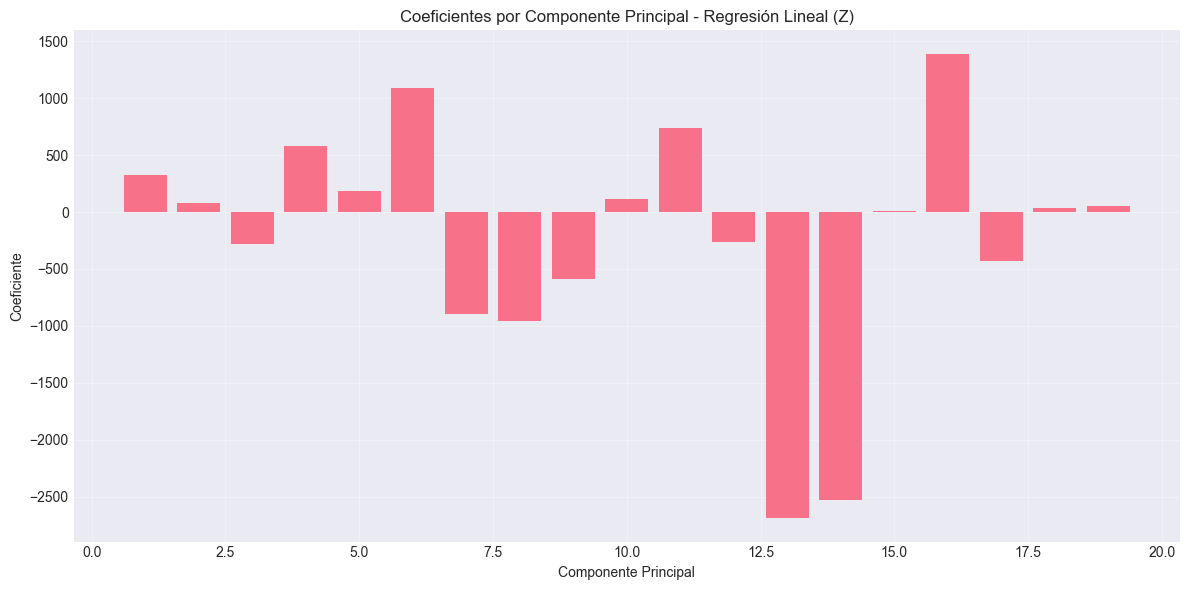

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(lr_z.coef_) + 1), lr_z.coef_)
plt.xlabel('Componente Principal')
plt.ylabel('Coeficiente')
plt.title('Coeficientes por Componente Principal - Regresión Lineal (Z)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/lr_z_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Comparación de Modelos

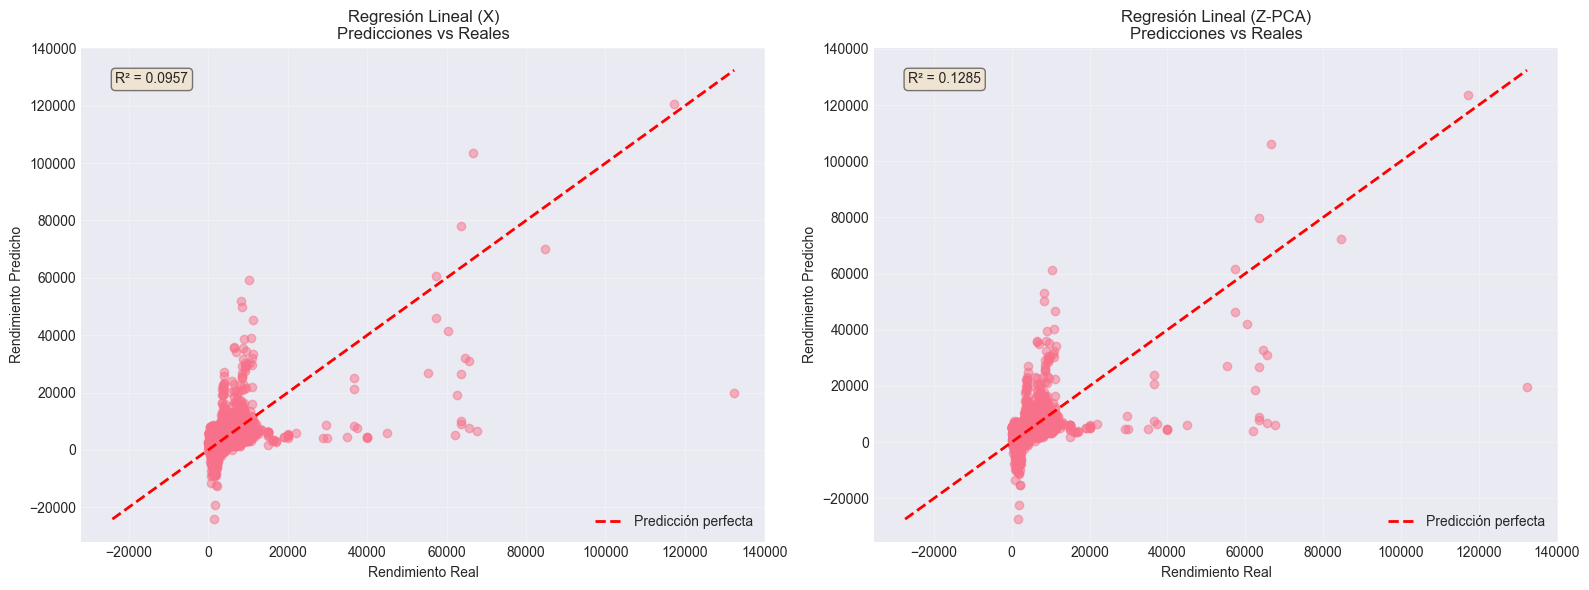

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_predictions(y_val, y_val_pred_lr_x, "Regresión Lineal (X)", ax=axes[0])
plot_predictions(y_val, y_val_pred_lr_z, "Regresión Lineal (Z-PCA)", ax=axes[1])

plt.tight_layout()
plt.savefig('../figures/lr_predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
comparison_df = pd.DataFrame([
    results_lr_x_val,
    results_lr_z_val
])

print("\n" + "="*70)
print("COMPARACIÓN DE MODELOS DE REGRESIÓN LINEAL (TEST SET)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


COMPARACIÓN DE MODELOS DE REGRESIÓN LINEAL (TEST SET)
                                 model        rmse         mae       r2
    Linear Regression (X) - Validation 3186.590903 1822.042463 0.095716
Linear Regression (Z-PCA) - Validation 3128.231027 1785.745667 0.128535


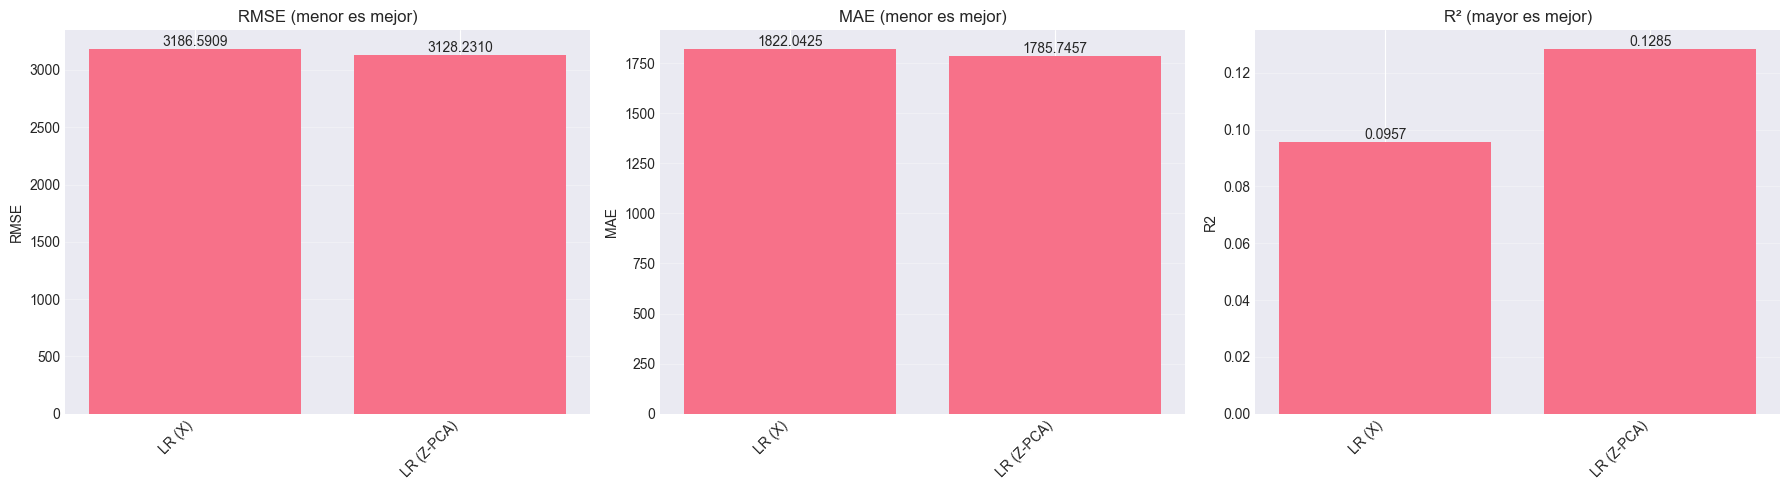

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['rmse', 'mae', 'r2']
titles = ['RMSE (menor es mejor)', 'MAE (menor es mejor)', 'R² (mayor es mejor)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    values = comparison_df[metric].values
    models = comparison_df['model'].values
    
    axes[idx].bar(range(len(values)), values)
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(['LR (X)', 'LR (Z-PCA)'], rotation=45, ha='right')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../figures/lr_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Análisis de Residuos

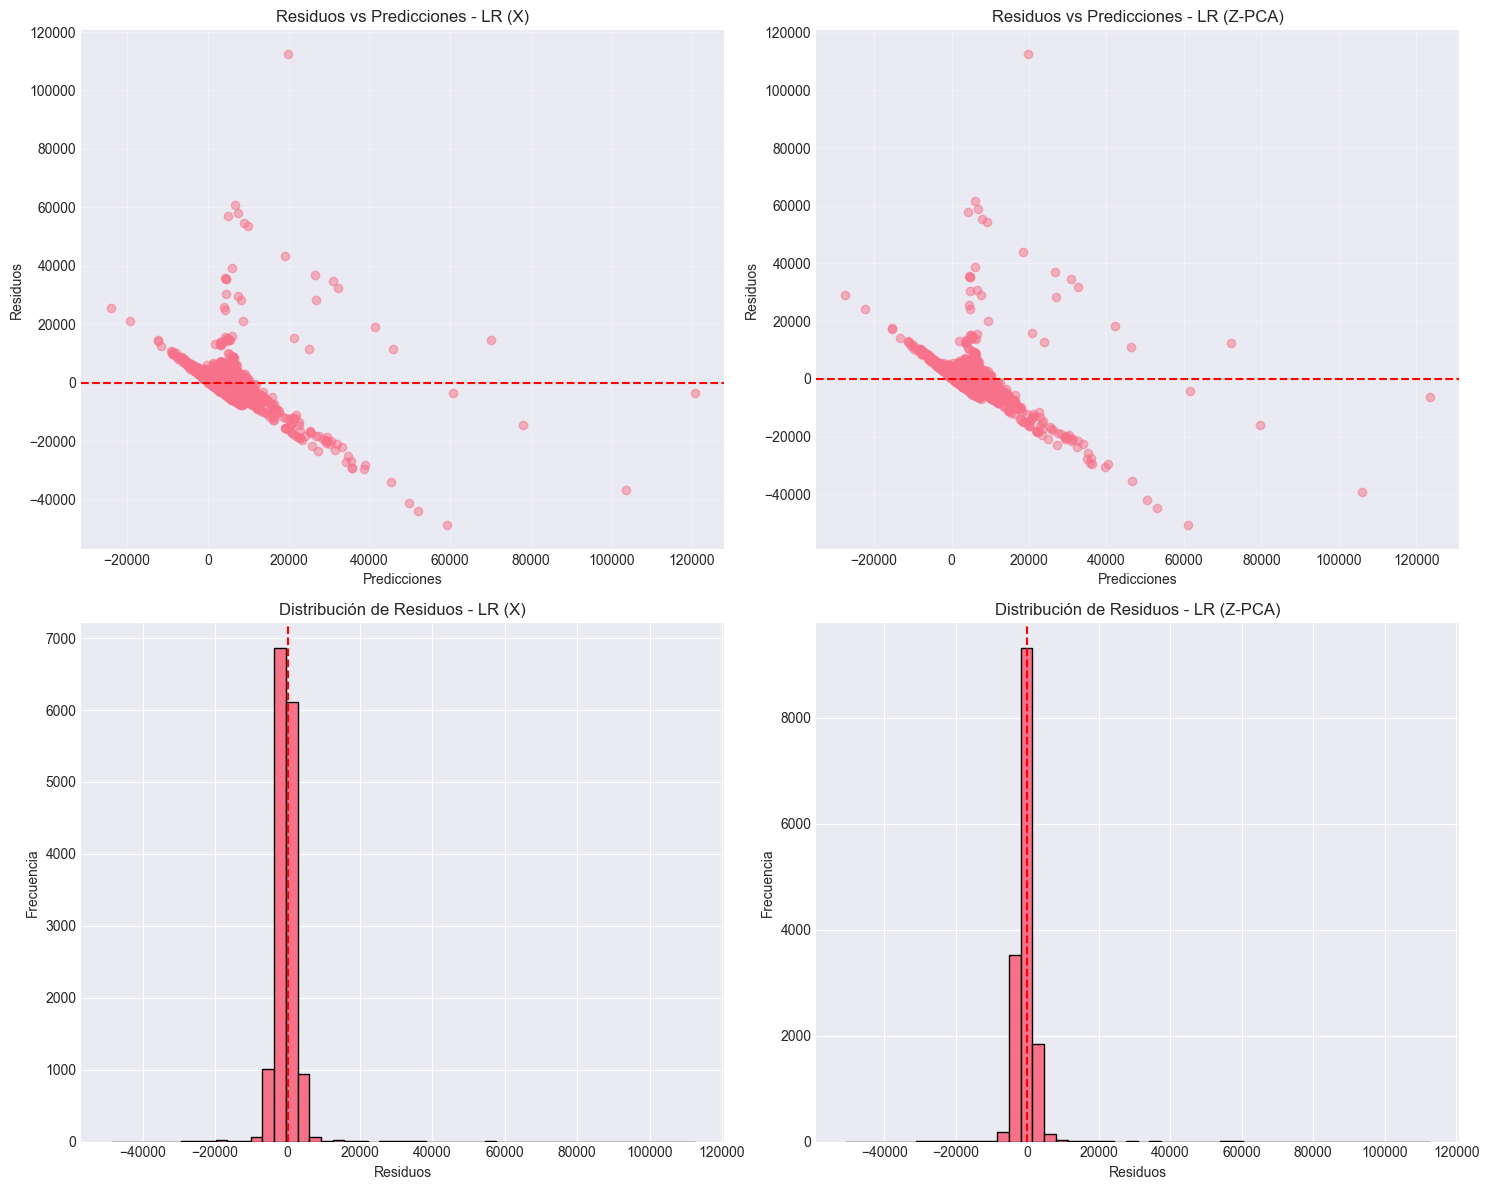

Media de residuos LR(X): -526.3981
Std de residuos LR(X): 3142.8119

Media de residuos LR(Z): -599.6615
Std de residuos LR(Z): 3070.2175


In [13]:
residuals_lr_x = y_val - y_val_pred_lr_x
residuals_lr_z = y_val - y_val_pred_lr_z

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].scatter(y_val_pred_lr_x, residuals_lr_x, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicciones')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Predicciones - LR (X)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_val_pred_lr_z, residuals_lr_z, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicciones')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Predicciones - LR (Z-PCA)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(residuals_lr_x, bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos - LR (X)')
axes[1, 0].axvline(x=0, color='r', linestyle='--')

axes[1, 1].hist(residuals_lr_z, bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Residuos - LR (Z-PCA)')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('../figures/lr_residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Media de residuos LR(X): {residuals_lr_x.mean():.4f}")
print(f"Std de residuos LR(X): {residuals_lr_x.std():.4f}")
print(f"\nMedia de residuos LR(Z): {residuals_lr_z.mean():.4f}")
print(f"Std de residuos LR(Z): {residuals_lr_z.std():.4f}")

## 7. Guardar Modelos

In [14]:
import pickle

with open('../models/lr_x.pkl', 'wb') as f:
    pickle.dump(lr_x, f)

with open('../models/lr_z.pkl', 'wb') as f:
    pickle.dump(lr_z, f)

print("Modelos guardados exitosamente.")

Modelos guardados exitosamente.


In [15]:
results_summary = {
    'lr_x_train': results_lr_x_train,
    'lr_x_val': results_lr_x_val,
    'lr_z_train': results_lr_z_train,
    'lr_z_val': results_lr_z_val
}

with open('../results/linear_regression_results.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

print("Resultados guardados exitosamente.")

Resultados guardados exitosamente.
